<a href="https://colab.research.google.com/github/Satya-Siba-Nayak/MachineLearning-Python/blob/main/Insurance-Charge/Insurance_charge_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
#Loading Dataset
df = pd.read_csv("/content/insurance.csv")

print("Dataset loaded successfully!")
print()


Dataset loaded successfully!



In [ ]:
#Display Info
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Shape:
(1338, 7)

Column Names:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical Summary:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.

In [ ]:
# Independent Variable
X = df[["bmi"]]

# Dependent Variable / Target
y = df["charges"]

print("\nIndependent Variable:")
print("BMI")

print("\nDependent Variable:")
print("Charges")



Independent Variable:
BMI

Dependent Variable:
Charges


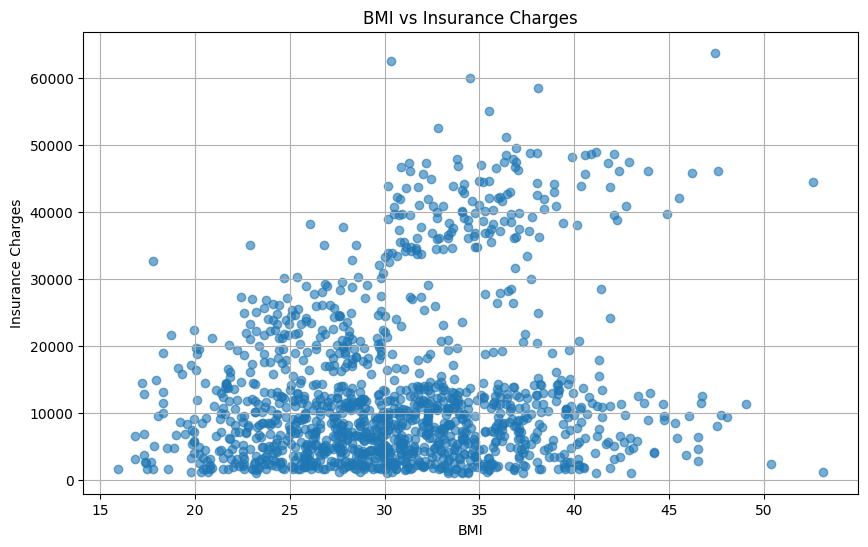

In [ ]:
#Visulaize Original Data
plt.figure(figsize=(10, 6))

plt.scatter(
    X["bmi"],
    y,
    alpha=0.6
)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges")

plt.grid(True)
plt.show()


In [ ]:
#Splitting in Training & Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))



Training samples: 1070
Testing samples: 268


In [ ]:
#Simple Linear Regression
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("\n==============================")
print("LINEAR REGRESSION")
print("==============================")

print("Slope:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)

print("R² Score:",
      r2_score(y_test, y_pred_linear))

print("MAE:",
      mean_absolute_error(y_test, y_pred_linear))

print("MSE:",
      mean_squared_error(y_test, y_pred_linear))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, y_pred_linear)))



LINEAR REGRESSION
Slope: 392.43654416987977
Intercept: 1353.0730722046683
R² Score: 0.03970193117941878
MAE: 9784.65259627133
MSE: 149085057.03839505
RMSE: 12210.039190698571


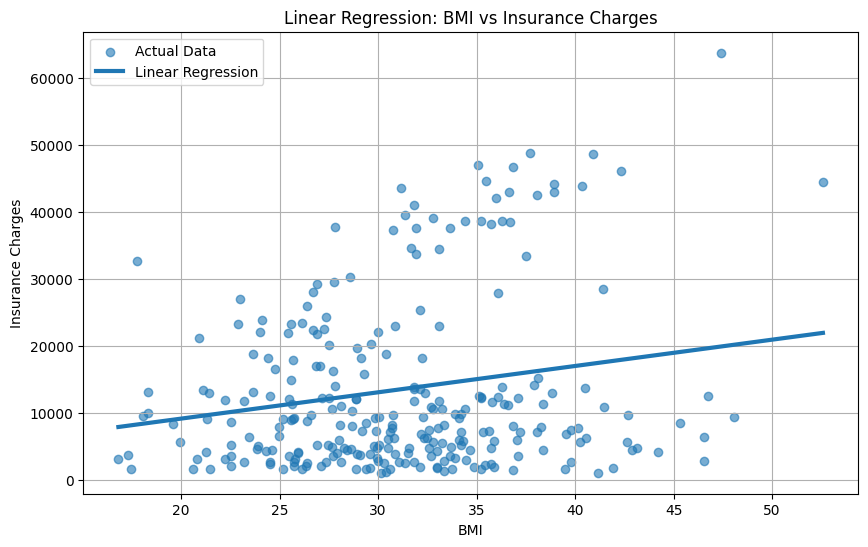

In [ ]:
#Visualize Linear Regression
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test["bmi"],
    y_test,
    alpha=0.6,
    label="Actual Data"
)

# Sort values for a smooth regression line
sort_index = np.argsort(X_test["bmi"].values)

X_test_sorted = X_test.iloc[sort_index]

y_linear_sorted = linear_model.predict(X_test_sorted)

plt.plot(
    X_test_sorted["bmi"],
    y_linear_sorted,
    linewidth=3,
    label="Linear Regression"
)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.title("Linear Regression: BMI vs Insurance Charges")

plt.legend()
plt.grid(True)

plt.show()


In [ ]:
#Polynomial Regression
def polynomial_regression(degree):

    # Create polynomial features
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create Linear Regression model
    model = LinearRegression()

    # Train the model
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Calculate evaluation values
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    test_mae = mean_absolute_error(y_test, y_test_pred)

    test_mse = mean_squared_error(y_test, y_test_pred)

    test_rmse = np.sqrt(test_mse)

    return (
        poly,
        model,
        y_test_pred,
        train_r2,
        test_r2,
        test_mae,
        test_mse,
        test_rmse
    )


In [ ]:
#Training Polynomial Models
degrees = [2, 3, 4, 5]

results = []

for degree in degrees:

    (
        poly,
        model,
        predictions,
        train_r2,
        test_r2,
        mae,
        mse,
        rmse
    ) = polynomial_regression(degree)

    results.append([
        degree,
        train_r2,
        test_r2,
        mae,
        mse,
        rmse
    ])


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Degree",
        "Training R2",
        "Testing R2",
        "MAE",
        "MSE",
        "RMSE"
    ]
)

print("\n==============================")
print("POLYNOMIAL REGRESSION RESULTS")
print("==============================")

print(results_df)



POLYNOMIAL REGRESSION RESULTS
   Degree  Training R2  Testing R2          MAE           MSE          RMSE
0       2     0.041558    0.030763  9823.701955  1.504728e+08  12266.733504
1       3     0.045290    0.018011  9863.434995  1.524525e+08  12347.166300
2       4     0.045513    0.013501  9864.611464  1.531528e+08  12375.489932
3       5     0.045612    0.016551  9851.097365  1.526792e+08  12356.343314


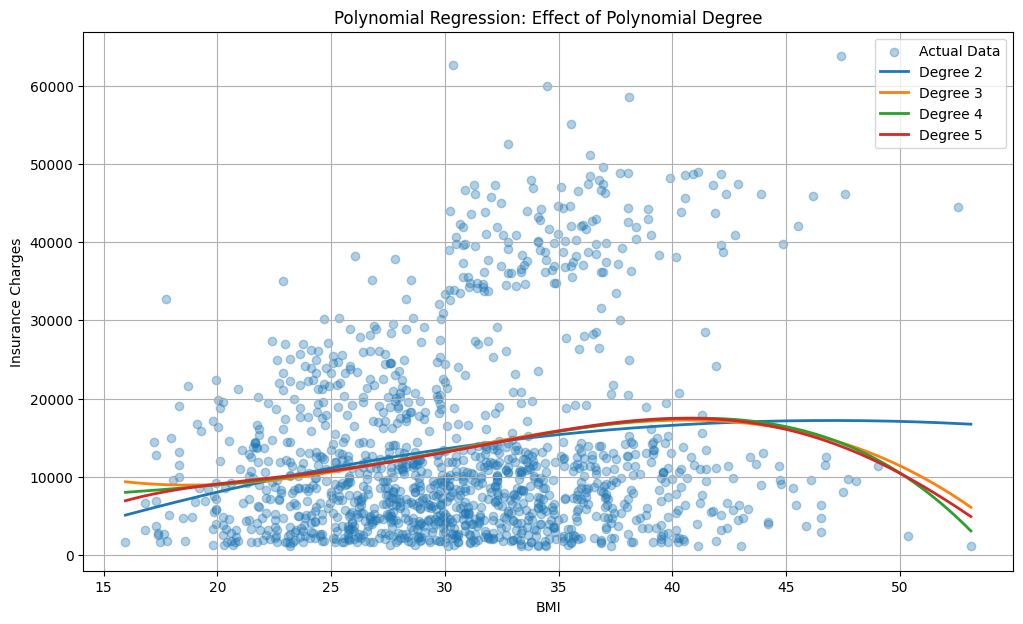

In [ ]:
#visualize polynomial curves

# Create a smooth range of BMI values
bmi_range = np.linspace(
    X["bmi"].min(),
    X["bmi"].max(),
    300
).reshape(-1, 1)

# Wrap in a DataFrame with correct column name to avoid warnings
bmi_range_df = pd.DataFrame(bmi_range, columns=["bmi"])

plt.figure(figsize=(12, 7))

# Plot actual data
plt.scatter(
    X["bmi"],
    y,
    alpha=0.35,
    label="Actual Data"
)


# Plot polynomial curves
for degree in degrees:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_poly = poly.fit_transform(X_train)

    model = LinearRegression()

    model.fit(X_poly, y_train)

    bmi_poly = poly.transform(bmi_range_df)

    predictions = model.predict(bmi_poly)

    plt.plot(
        bmi_range,
        predictions,
        linewidth=2,
        label=f"Degree {degree}"
    )


plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.title(
    "Polynomial Regression: Effect of Polynomial Degree"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#predict insurance for new BMI
new_bmi = np.array([[30]])
new_bmi_df = pd.DataFrame(new_bmi, columns=["bmi"])

print("\n==============================")
print("PREDICTION FOR NEW BMI")
print("==============================")


for degree in [2, 3, 4, 5]:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)

    model = LinearRegression()

    model.fit(X_train_poly, y_train)

    new_bmi_poly = poly.transform(new_bmi_df)

    predicted_charge = model.predict(new_bmi_poly)

    print(
        f"Degree {degree}: "
        f"Predicted insurance charge = "
        f"{predicted_charge[0]:.2f}"
    )


PREDICTION FOR NEW BMI
Degree 2: Predicted insurance charge = 13569.38
Degree 3: Predicted insurance charge = 13275.11
Degree 4: Predicted insurance charge = 13192.39
Degree 5: Predicted insurance charge = 13113.19


In [ ]:
#Display Polynomial Features
poly_demo = PolynomialFeatures(
    degree=3,
    include_bias=False
)

demo_features = poly_demo.fit_transform(
    np.array([[20], [25], [30]])
)

demo_df = pd.DataFrame(
    demo_features,
    columns=["BMI", "BMI²", "BMI³"]
)

print("\n==============================")
print("POLYNOMIAL FEATURE GENERATION")
print("==============================")

print(demo_df)



POLYNOMIAL FEATURE GENERATION
    BMI   BMI²     BMI³
0  20.0  400.0   8000.0
1  25.0  625.0  15625.0
2  30.0  900.0  27000.0
